# Exact and hierarchical MSTs on synthetic 2D Gaussian data

Generate Gaussian clouds with randomly oriented and scaled covariance matrices, then compare exact and hierarchical graph construction. Each row is an algorithm and each column shows a cumulative MST rank; later ranks use thinner, lighter edges.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cdist
from matplotlib.collections import LineCollection
from sklearn.cluster import MiniBatchKMeans

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'mst_embedding').is_dir()),
    None,
)
if repo_root is not None and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mst_embedding._estimator import (
    _hierarchical_imst_edges,
    _iterated_mst_edges,
)

## Generate Gaussian clouds

Each cluster gets its own random center, orientation, and axis scales.

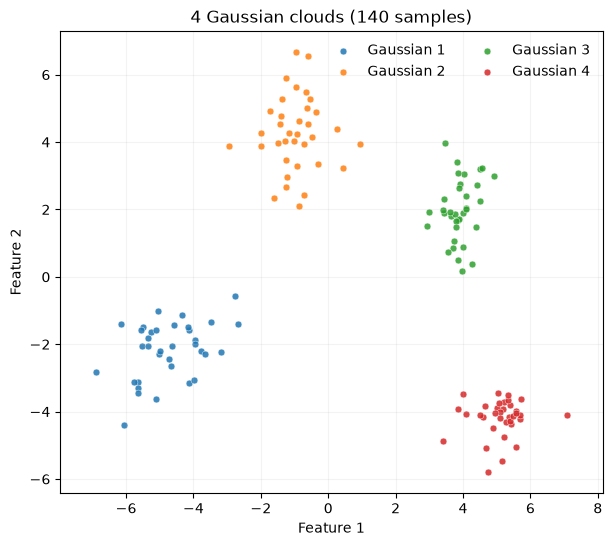

In [2]:
rng = np.random.default_rng(17)
n_clusters = 4
points_per_cluster = 35

centers = np.array([[-5.0, -2.0], [-1.0, 4.0], [4.0, 2.0], [5.0, -4.0]])
cluster_colors = plt.get_cmap('tab10')(np.arange(n_clusters))
clouds = []
labels = []
for cluster_id, center in enumerate(centers):
    angle = rng.uniform(0, 2 * np.pi)
    rotation = np.array([[np.cos(angle), -np.sin(angle)],
                         [np.sin(angle),  np.cos(angle)]])
    axis_scales = rng.uniform(0.45, 1.6, size=2)
    covariance = rotation @ np.diag(axis_scales ** 2) @ rotation.T
    clouds.append(rng.multivariate_normal(center, covariance, size=points_per_cluster))
    labels.extend([cluster_id] * points_per_cluster)

X = np.vstack(clouds)
labels = np.asarray(labels)
n_msts = 8

fig, ax = plt.subplots(figsize=(7, 6))
for cluster_id, color in enumerate(cluster_colors):
    mask = labels == cluster_id
    ax.scatter(X[mask, 0], X[mask, 1], s=24, color=color,
               alpha=0.85, edgecolor='white', linewidth=0.35,
               label=f'Gaussian {cluster_id + 1}')
ax.set(title=f'{n_clusters} Gaussian clouds ({len(X)} samples)',
       xlabel='Feature 1', ylabel='Feature 2')
ax.set_aspect('equal', adjustable='datalim')
ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.15)
plt.show()

## Compare exact and hierarchical graph construction

The exact row uses edge-disjoint MSTs over all samples. The hierarchical row clusters the samples, builds coarse MSTs over cluster centers, then builds local MSTs over neighboring cluster pairs. In the hierarchical graph, each edge is shown at its strongest local MST rank.

In [3]:
distances = cdist(X, X, metric='euclidean')

# Exact graph: the helper returns MSTs consecutively, with n_samples - 1 edges each.
exact_edges, exact_weights = _iterated_mst_edges(
    distances, n_msts=n_msts, rank_weight_exponent=1.0
)
edges_per_tree = len(X) - 1
exact_by_rank = [
    exact_edges[rank * edges_per_tree:(rank + 1) * edges_per_tree]
    for rank in range(n_msts)
]

# Hierarchical graph with the same maximum rank, using a reproducible clustering.
n_hierarchical_clusters = 8
n_coarse_msts = 4
clusterer = MiniBatchKMeans(
    n_clusters=n_hierarchical_clusters, random_state=17,
    n_init=3, batch_size=64,
).fit(X)
hierarchical_edges, hierarchical_weights = _hierarchical_imst_edges(
    X, clusterer.labels_, clusterer.cluster_centers_,
    n_clusters=n_hierarchical_clusters,
    n_coarse_msts=n_coarse_msts, n_local_msts=n_msts,
    rank_weight_exponent=1.0, n_jobs=1,
)

# With exponent 1, the retained edge weight is 1 / rank. Convert it back to rank.
hierarchical_ranks = np.rint(1.0 / hierarchical_weights).astype(int)
hierarchical_by_rank = [
    hierarchical_edges[hierarchical_ranks == rank]
    for rank in range(1, n_msts + 1)
]

iterations_to_show = [1, 2, 4, 8]
rank_colors = plt.get_cmap('viridis')(np.linspace(0.08, 0.88, n_msts))
algorithm_edges = [exact_by_rank, hierarchical_by_rank]
algorithm_names = ['Exact', 'Hierarchical']
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=True, sharey=True)
for row, (name, edges_by_rank) in enumerate(zip(algorithm_names, algorithm_edges)):
    for col, iteration in enumerate(iterations_to_show):
        ax = axes[row, col]
        for rank, edges in enumerate(edges_by_rank[:iteration], start=1):
            if len(edges) == 0:
                continue
            collection = LineCollection(
                X[edges], colors=[rank_colors[rank - 1]],
                linewidths=2.8 / rank, alpha=0.88, zorder=rank,
            )
            ax.add_collection(collection)
        for cluster_id, color in enumerate(cluster_colors):
            mask = labels == cluster_id
            ax.scatter(X[mask, 0], X[mask, 1], s=13, color=color,
                       edgecolor='white', linewidth=0.2, zorder=10)
        ax.autoscale_view()
        ax.set_title(f'{name}: ranks 1–{iteration}')
        ax.set_xlabel('Feature 1')
        ax.set_aspect('equal', adjustable='datalim')
        ax.grid(alpha=0.12)
        if col == 0:
            ax.set_ylabel('Feature 2')

fig.suptitle('Exact vs hierarchical MST graphs (later ranks are thinner)', fontsize=16)
fig.tight_layout()
plt.show()

ValueError: Could not construct MST 4: removing earlier trees left the available graph disconnected. Reduce n_msts.

The exact method connects every sample during each edge-disjoint MST pass. The hierarchical method first limits cluster comparisons with coarse centroid MSTs, then collects local MST edges from neighboring cluster pairs. Both rows use the same points and rank-based line widths.